# 📊 Scoring de Crédit — Modélisation du Risque de Défaut

> **Objectif :** Prédire le risque de défaut de paiement (`Risk_Flag`) à partir des caractéristiques socio-économiques et financières des demandeurs de prêt, à l'aide d'un modèle CatBoost optimisé.

---

## 🗂️ Plan du Notebook

1. [Configuration & Imports](#1-config)
2. [Chargement des données](#2-data)
3. [Exploration initiale (EDA)](#3-eda)
4. [Analyse univariée — Variables catégorielles & discrètes](#4-univariee-cat)
5. [Analyse univariée — Variables continues](#5-univariee-cont)
6. [Analyse multivariée](#6-multivariee)
7. [Feature Engineering](#7-fe)
8. [Séparation Train / Validation](#8-split)
9. [Pipelines de prétraitement](#9-pipeline)
10. [Entraînement & Évaluation des modèles](#10-eval)
11. [Optimisation des hyperparamètres](#11-optim)
12. [Analyse des seuils de décision](#12-threshold)
13. [Interprétabilité — Valeurs SHAP](#13-shap)
14. [Sauvegarde du modèle & du Transformer](#14-save)

---

## 1. ⚙️ Configuration & Imports <a id='1-config'></a>

In [1]:
# Manipulation et analyse des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration globale des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

---
## 2. 📁 Chargement des Données <a id='2-data'></a>

### 2.1 Lecture des fichiers CSV

In [2]:
# Chargement des jeux d'entraînement et de test
train = pd.read_csv("../Data/TrainingData.csv")
test  = pd.read_csv("../Data/TestData.csv")

In [3]:
train.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [12]:
# Vérification des dimensions des deux datasets
print(f"Train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes × {test.shape[1]} colonnes")

Train : 252,000 lignes × 13 colonnes
Test  : 28,000 lignes × 12 colonnes


### 2.2 Dictionnaire des variables

| Colonne               | Description                                                  | Type   |
|-----------------------|--------------------------------------------------------------|--------|
| `Income`              | Revenu annuel de l'utilisateur (en roupies indiennes, INR)   | int    |
| `Age`                 | Âge de l'utilisateur                                         | int    |
| `Experience`          | Expérience professionnelle totale en années                  | int    |
| `Profession`          | Intitulé du poste occupé                                     | string |
| `Married/Single`      | Situation maritale (marié ou célibataire)                    | string |
| `House_Ownership`     | Statut immobilier (propriétaire / locataire / autre)         | string |
| `Car_Ownership`       | Possession d'un véhicule (yes / no)                          | string |
| `Risk_Flag`           | **Variable cible** — Défaut de paiement (1 = risqué)         | int    |
| `CURRENT_JOB_YRS`     | Ancienneté dans le poste actuel (années)                     | int    |
| `CURRENT_HOUSE_YRS`   | Ancienneté dans la résidence actuelle (années)               | int    |
| `CITY`                | Ville de résidence                                           | string |
| `STATE`               | État de résidence (Inde)                                     | string |

---
## 3. 🔍 Exploration Initiale (EDA) <a id='3-eda'></a>

### 3.1 Aperçu des premières lignes

In [4]:
# Aperçu des 5 premières lignes du jeu d'entraînement
train.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


### 3.2 Informations structurelles

In [5]:
# Types de données, valeurs non nulles, consommation mémoire
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Id                 252000 non-null  int64
 1   Income             252000 non-null  int64
 2   Age                252000 non-null  int64
 3   Experience         252000 non-null  int64
 4   Married/Single     252000 non-null  str  
 5   House_Ownership    252000 non-null  str  
 6   Car_Ownership      252000 non-null  str  
 7   Profession         252000 non-null  str  
 8   CITY               252000 non-null  str  
 9   STATE              252000 non-null  str  
 10  CURRENT_JOB_YRS    252000 non-null  int64
 11  CURRENT_HOUSE_YRS  252000 non-null  int64
 12  Risk_Flag          252000 non-null  int64
dtypes: int64(7), str(6)
memory usage: 25.0 MB


### 3.3 Qualité des données

In [6]:
# Vérification des doublons
nb_doublons = train.duplicated().sum()
print(f"Nombre de lignes dupliquées : {nb_doublons}")
# ✅ Aucun doublon détecté

Nombre de lignes dupliquées : 0


In [7]:
# Statistiques descriptives : min, max, moyenne, écart-type, quartiles
train.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


### 3.4 Nettoyage — Suppression de la colonne identifiant

In [8]:
# Suppression de la colonne Id (non informative pour la modélisation)
train = train.drop('Id', axis=1)
print(f"Dimensions après suppression de 'Id' : {train.shape}")

Dimensions après suppression de 'Id' : (252000, 12)


---
## 4. 📊 Analyse Univariée — Variables Catégorielles & Discrètes <a id='4-univariee-cat'></a>

> Étude de la distribution de chaque variable qualitative et de la variable cible.

### 4.1 Variable cible — `Risk_Flag`

> `0` = profil sain &nbsp;|&nbsp; `1` = risque de défaut de paiement

In [9]:
# Distribution de la variable cible
print(train['Risk_Flag'].value_counts())
print(f"\nTaux de défaut : {train['Risk_Flag'].mean():.2%}")
# ⚠️ Déséquilibre de classes → à prendre en compte lors de la modélisation (class_weight, métriques adaptées)

Risk_Flag
0    221004
1     30996
Name: count, dtype: int64

Taux de défaut : 12.30%


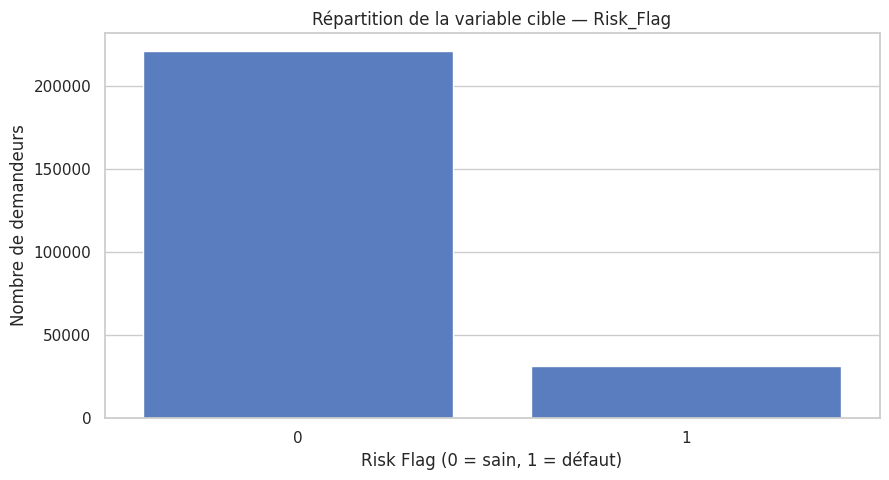

In [10]:
sns.countplot(x='Risk_Flag', data=train)
plt.title('Répartition de la variable cible — Risk_Flag')
plt.xlabel('Risk Flag (0 = sain, 1 = défaut)')
plt.ylabel('Nombre de demandeurs')
plt.show()

### 4.2 Situation maritale — `Married/Single`

In [11]:
print(train['Married/Single'].value_counts())

Married/Single
single     226272
married     25728
Name: count, dtype: int64


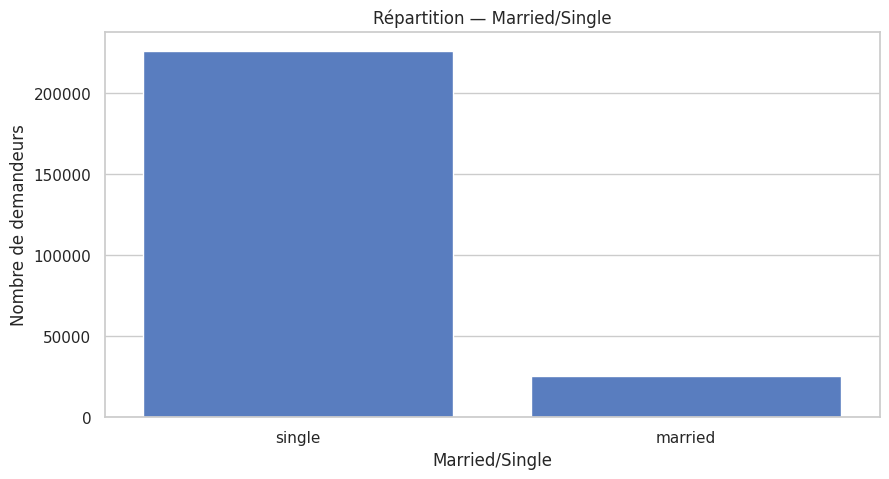

In [12]:
sns.countplot(x='Married/Single', data=train)
plt.title('Répartition — Married/Single')
plt.ylabel('Nombre de demandeurs')
plt.show()

### 4.3 Statut immobilier — `House_Ownership`

In [13]:
print(train['House_Ownership'].value_counts())

House_Ownership
rented          231898
owned            12918
norent_noown      7184
Name: count, dtype: int64


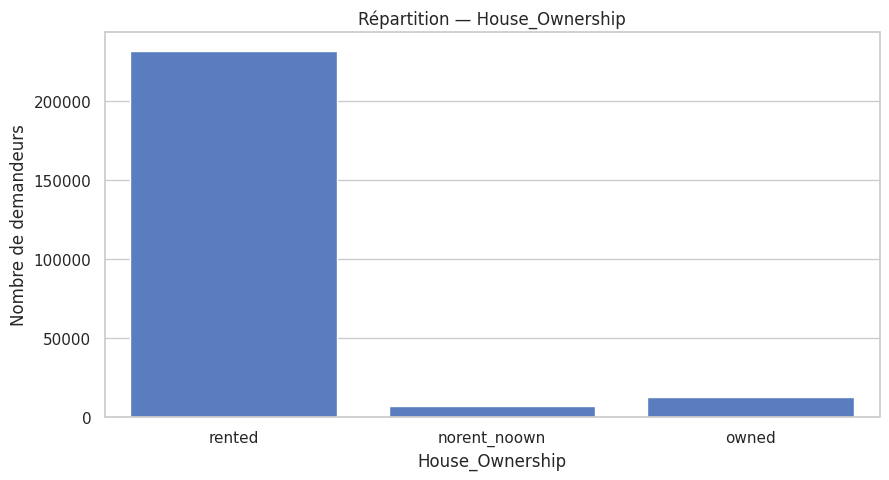

In [14]:
sns.countplot(x='House_Ownership', data=train)
plt.title('Répartition — House_Ownership')
plt.ylabel('Nombre de demandeurs')
plt.show()

### 4.4 Possession d'un véhicule — `Car_Ownership`

In [15]:
print(train['Car_Ownership'].value_counts())

Car_Ownership
no     176000
yes     76000
Name: count, dtype: int64


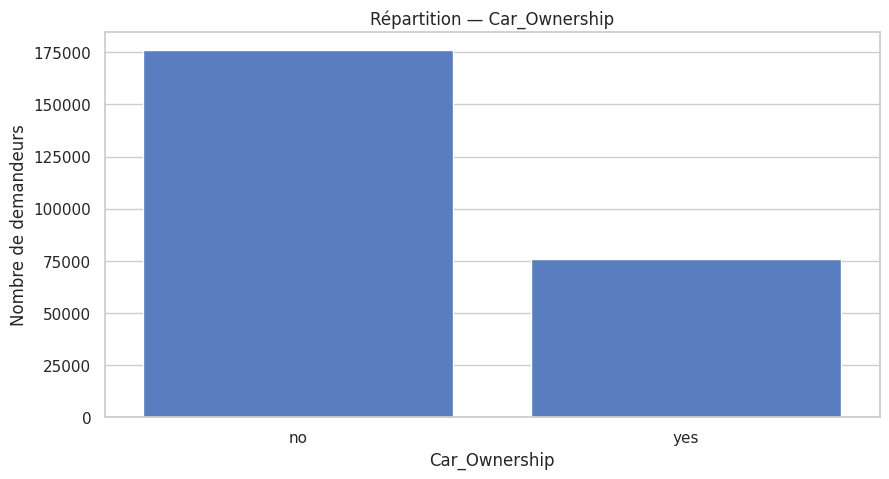

In [16]:
sns.countplot(x='Car_Ownership', data=train)
plt.title('Répartition — Car_Ownership')
plt.ylabel('Nombre de demandeurs')
plt.show()

### 4.5 Profession — `Profession`

> Variable à forte cardinalité — un regroupement sera effectué en Feature Engineering.

In [17]:
# Top 10 des professions les plus représentées
print(train['Profession'].value_counts().head(10))

Profession
Physician                     5957
Statistician                  5806
Web_designer                  5397
Psychologist                  5390
Computer_hardware_engineer    5372
Drafter                       5359
Magistrate                    5357
Fashion_Designer              5304
Air_traffic_controller        5281
Comedian                      5259
Name: count, dtype: int64


In [18]:
nb_professions = train['Profession'].nunique()
print(f"Nombre de professions uniques : {nb_professions}")
# ⚠️ 51 modalités → risque de curse of dimensionality avec un encodage naïf
# 💡 Solution : regroupement en grandes catégories métier (voir section Feature Engineering)

Nombre de professions uniques : 51


### 4.6 Géographie — `CITY` & `STATE`

> Variables à très haute cardinalité — agrégation en régions prévue.

In [19]:
# Top 10 des villes les plus représentées
print(train['CITY'].value_counts().head(10))
print(f"\nNombre de villes uniques : {train['CITY'].nunique()}")

CITY
Vijayanagaram    1259
Bhopal           1208
Bulandshahr      1185
Saharsa[29]      1180
Vijayawada       1172
Srinagar         1136
Indore           1130
Hajipur[31]      1098
New_Delhi        1098
Satara           1096
Name: count, dtype: int64

Nombre de villes uniques : 317


In [20]:
# Distribution par état indien
print(train['STATE'].value_counts())
print(f"\nNombre d'états uniques : {train['STATE'].nunique()}")

STATE
Uttar_Pradesh        28400
Maharashtra          25562
Andhra_Pradesh       25297
West_Bengal          23483
Bihar                19780
Tamil_Nadu           16537
Madhya_Pradesh       14122
Karnataka            11855
Gujarat              11408
Rajasthan             9174
Jharkhand             8965
Haryana               7890
Telangana             7524
Assam                 7062
Kerala                5805
Delhi                 5490
Punjab                4720
Odisha                4658
Chhattisgarh          3834
Uttarakhand           1874
Jammu_and_Kashmir     1780
Puducherry            1433
Mizoram                849
Manipur                849
Himachal_Pradesh       833
Tripura                809
Uttar_Pradesh[5]       743
Chandigarh             656
Sikkim                 608
Name: count, dtype: int64

Nombre d'états uniques : 29


### 4.7 Ancienneté professionnelle et résidentielle

In [21]:
# Distribution de l'ancienneté dans le poste actuel
print(train['CURRENT_JOB_YRS'].value_counts().sort_index())

CURRENT_JOB_YRS
0     11043
1     11575
2     11087
3     29460
4     28339
5     25091
6     23491
7     19925
8     18874
9     17132
10    15768
11    13595
12    10605
13     9099
14     6916
Name: count, dtype: int64


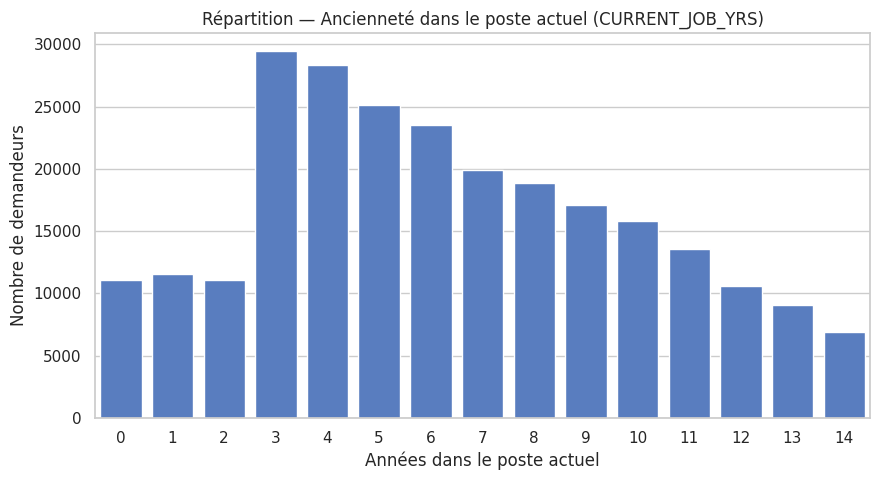

In [22]:
sns.countplot(x='CURRENT_JOB_YRS', data=train)
plt.title('Répartition — Ancienneté dans le poste actuel (CURRENT_JOB_YRS)')
plt.xlabel('Années dans le poste actuel')
plt.ylabel('Nombre de demandeurs')
plt.show()
# 💡 Feature engineering prévu : discrétisation en tranches

In [23]:
# Distribution de l'ancienneté dans la résidence actuelle
print(train['CURRENT_HOUSE_YRS'].value_counts().sort_index())

CURRENT_HOUSE_YRS
10    48674
11    51873
12    51791
13    50659
14    49003
Name: count, dtype: int64


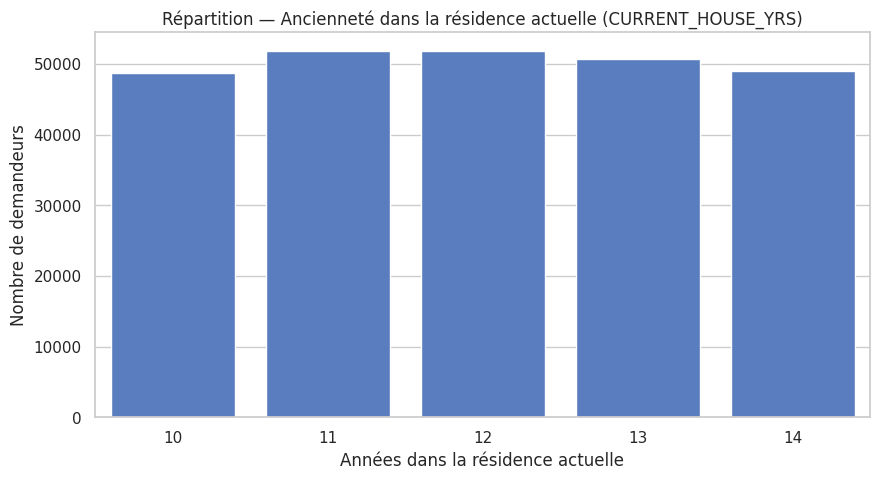

In [24]:
sns.countplot(x='CURRENT_HOUSE_YRS', data=train)
plt.title('Répartition — Ancienneté dans la résidence actuelle (CURRENT_HOUSE_YRS)')
plt.xlabel('Années dans la résidence actuelle')
plt.ylabel('Nombre de demandeurs')
plt.show()

### 4.8 Expérience professionnelle — `Experience`

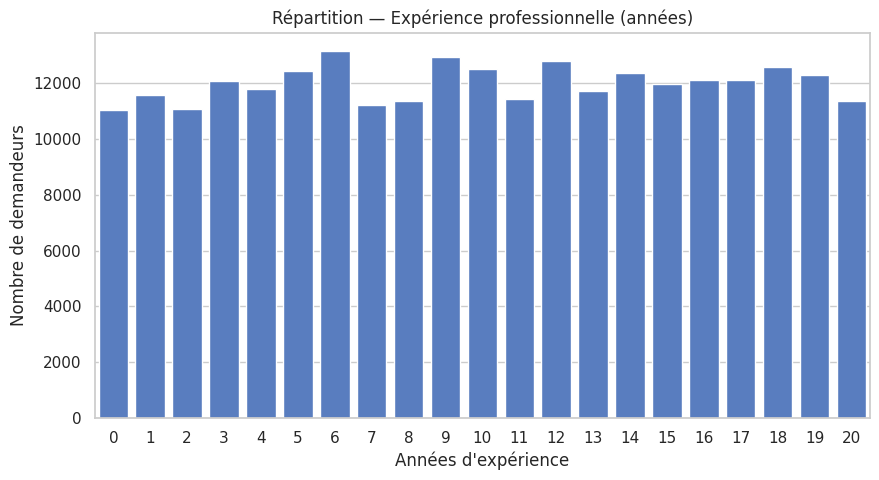

In [25]:
# Distribution de l'expérience totale en années
sns.countplot(x='Experience', data=train)
plt.title('Répartition — Expérience professionnelle (années)')
plt.xlabel("Années d'expérience")
plt.ylabel('Nombre de demandeurs')
plt.show()

In [26]:
print(train['Experience'].value_counts().sort_index())

Experience
0     11043
1     11575
2     11087
3     12069
4     11807
5     12441
6     13158
7     11232
8     11350
9     12936
10    12503
11    11449
12    12800
13    11713
14    12369
15    11993
16    12106
17    12131
18    12601
19    12287
20    11350
Name: count, dtype: int64


---
## 5. 📈 Analyse Univariée — Variables Continues <a id='5-univariee-cont'></a>

> Étude des distributions des variables numériques à valeurs continues.

In [27]:
# Vérification des types pour identifier les variables continues
train.dtypes

Income               int64
Age                  int64
Experience           int64
Married/Single         str
House_Ownership        str
Car_Ownership          str
Profession             str
CITY                   str
STATE                  str
CURRENT_JOB_YRS      int64
CURRENT_HOUSE_YRS    int64
Risk_Flag            int64
dtype: object

### 5.1 Âge des demandeurs — `Age`

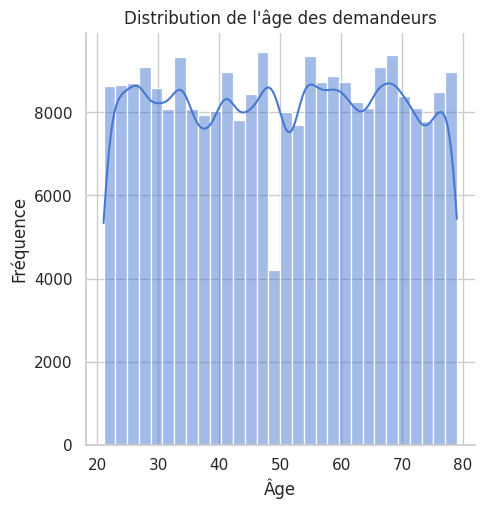

In [28]:
# Histogramme avec estimation de densité (KDE)
sns.displot(train['Age'], kde=True, bins=30)
plt.title("Distribution de l'âge des demandeurs")
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.show()
# 📝 L'âge est relativement bien distribué — les demandes de prêt concernent toutes les tranches d'âge

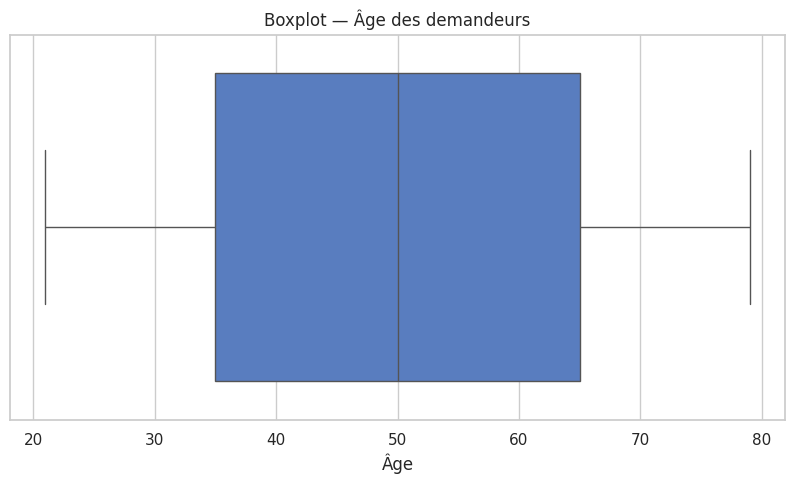

In [29]:
# Boîte à moustaches — détection des valeurs aberrantes
sns.boxplot(x=train['Age'])
plt.title('Boxplot — Âge des demandeurs')
plt.xlabel('Âge')
plt.show()

### 5.2 Revenu annuel — `Income`

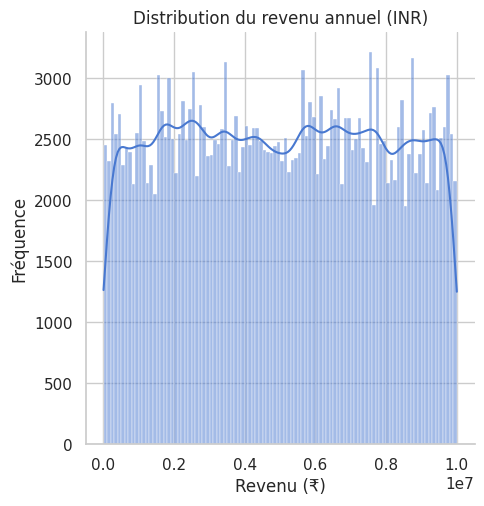

In [30]:
# Histogramme avec KDE (résolution fine : 100 bins)
sns.displot(train['Income'], kde=True, bins=100)
plt.title('Distribution du revenu annuel (INR)')
plt.xlabel('Revenu (₹)')
plt.ylabel('Fréquence')
plt.show()

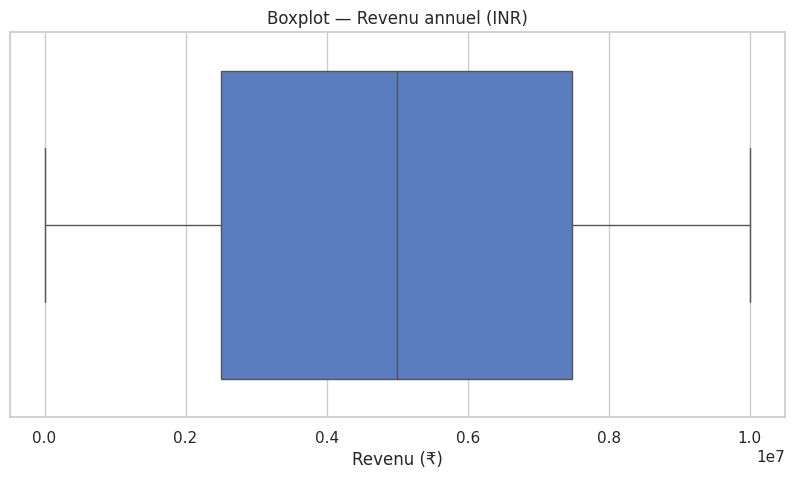

In [ ]:
# Boîte à moustaches — identification des revenus extrêmes
sns.boxplot(x=train['Income'])
plt.title('Boxplot — Revenu annuel (INR)')
plt.xlabel('Revenu (₹)')
plt.show()
# Pas Présence de revenus très élevés (outliers) 

---
## 6. 🔗 Analyse Multivariée <a id='6-multivariee'></a>

> Étude des relations entre `Risk_Flag` et les autres variables du dataset.

### 6.1 `Risk_Flag` × `Car_Ownership`

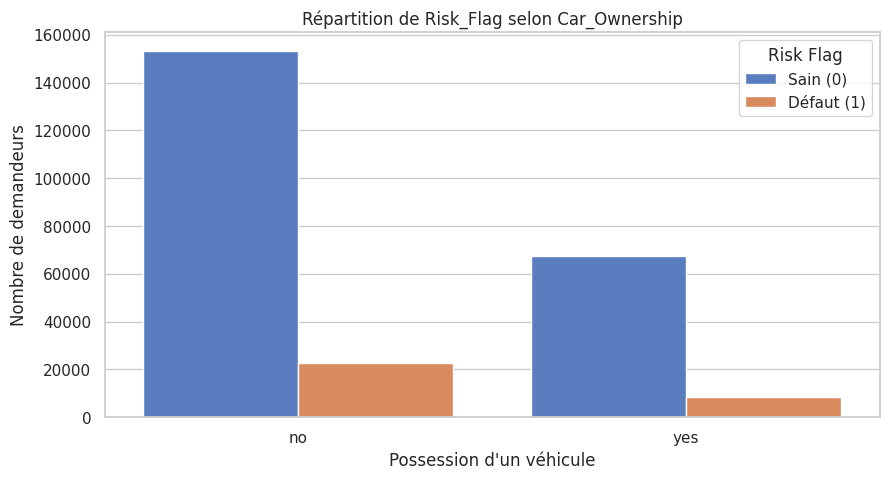

In [32]:
sns.countplot(x='Car_Ownership', hue='Risk_Flag', data=train)
plt.title('Répartition de Risk_Flag selon Car_Ownership')
plt.xlabel("Possession d'un véhicule")
plt.ylabel('Nombre de demandeurs')
plt.legend(title='Risk Flag', labels=['Sain (0)', 'Défaut (1)'])
plt.show()

In [33]:
# Table de contingence
pd.crosstab(train['Car_Ownership'], train['Risk_Flag'])
# 📝 Les personnes sans voiture effectuent davantage de demandes de prêt

Risk_Flag,0,1
Car_Ownership,,
no,153439,22561
yes,67565,8435


### 6.2 `Risk_Flag` × `House_Ownership`

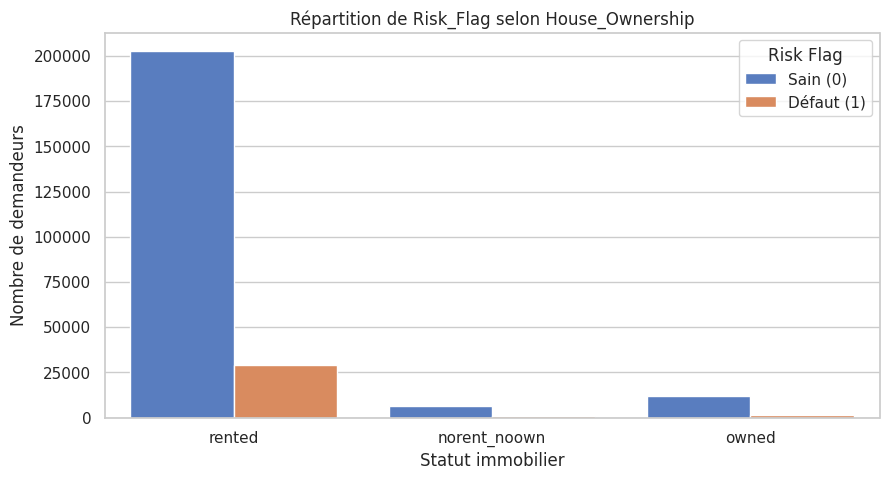

In [34]:
sns.countplot(x='House_Ownership', hue='Risk_Flag', data=train)
plt.title('Répartition de Risk_Flag selon House_Ownership')
plt.xlabel('Statut immobilier')
plt.ylabel('Nombre de demandeurs')
plt.legend(title='Risk Flag', labels=['Sain (0)', 'Défaut (1)'])
plt.show()

In [35]:
# Table de contingence
pd.crosstab(train['House_Ownership'], train['Risk_Flag'])

Risk_Flag,0,1
House_Ownership,,
norent_noown,6469,715
owned,11758,1160
rented,202777,29121


### 6.3 `Risk_Flag` × `Experience`

In [36]:
# Table de contingence : expérience vs risque
pd.crosstab(train['Experience'], train['Risk_Flag'])
# 📝 Pour tous les niveaux d'expérience, les profils sains sont majoritaires
#    → L'expérience seule n'est pas un facteur discriminant

Risk_Flag,0,1
Experience,,
0,9461,1582
1,9773,1802
2,9197,1890
3,10483,1586
4,10358,1449
5,10876,1565
6,11601,1557
7,9829,1403
8,10016,1334


### 6.4 Matrice de corrélation — Variables numériques

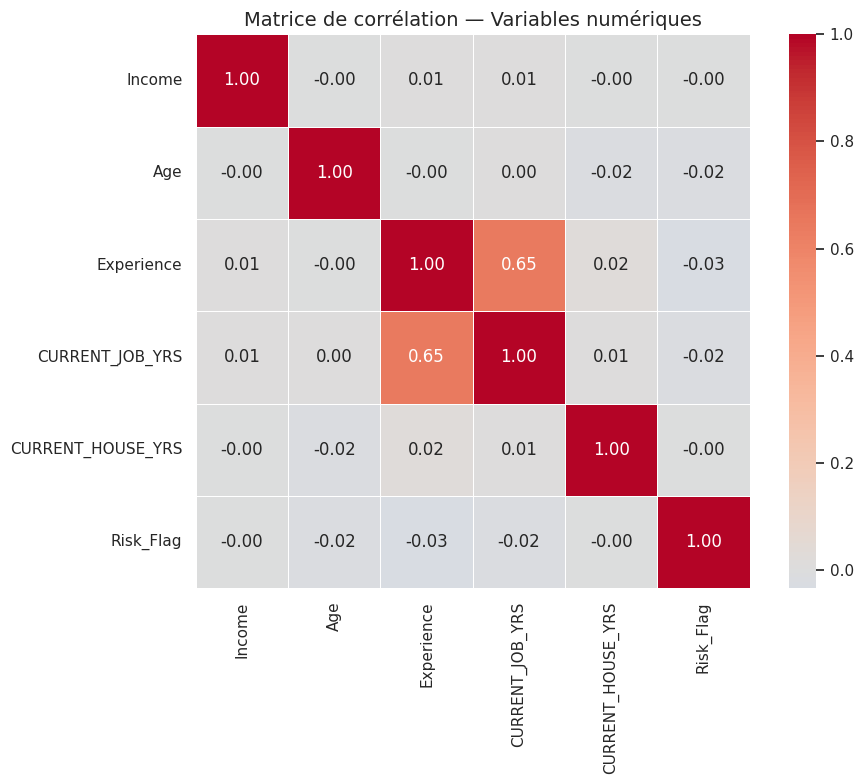

In [37]:
# Heatmap des corrélations de Pearson entre toutes les variables numériques
plt.figure(figsize=(10, 8))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Matrice de corrélation — Variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

### 6.5 Moyennes par groupe de risque

In [38]:
# Âge moyen selon le Risk_Flag
print("Âge moyen par groupe :")
print(train.groupby('Risk_Flag')['Age'].mean())
# 📝 Différence d'âge quasi nulle entre les groupes → variable peu discriminante seule

Âge moyen par groupe :
Risk_Flag
0    50.093442
1    48.960350
Name: Age, dtype: float64


In [39]:
# Expérience moyenne selon le Risk_Flag
print("Expérience moyenne par groupe :")
print(train.groupby('Risk_Flag')['Experience'].mean())
# 📝 Légère différence d'expérience entre groupes, non significative

Expérience moyenne par groupe :
Risk_Flag
0    10.162042
1     9.531101
Name: Experience, dtype: float64


### 6.6 Observations clés de l'analyse

- **`Experience` ↔ `CURRENT_JOB_YRS`** : corrélation positive forte — les profils expérimentés ont aussi plus d'ancienneté dans leur poste actuel.
- **`Risk_Flag`** est très faiblement corrélé (négativement) avec les autres variables numériques.
- L'âge des profils à risque est légèrement inférieur, mais la différence est quasi nulle en pratique (corrélation ≈ 0).

---
## 7. 🔧 Feature Engineering <a id='7-fe'></a>

> Création de nouvelles variables plus informatives à partir des variables brutes.

### 7.1 Regroupement des professions en catégories métier

In [40]:
# Regroupement des 51 professions en 9 grandes catégories métier
# Cela réduit la cardinalité et améliore la généralisation du modèle

def map_profession(profession):
    if profession in [
    'Mechanical_engineer', 'Civil_engineer', 'Design_Engineer',
    'Chemical_engineer', 'Biomedical_Engineer', 'Petroleum_Engineer',
    'Industrial_Engineer', 'Engineer', 'Architect',
    'Surveyor', 'Geologist', 'Drafter']:
        return 'Engineering'
    elif profession in [
    'Software_Developer', 'Web_designer', 'Computer_hardware_engineer',
    'Computer_operator', 'Technology_specialist', 'Technician']:
        return 'Technology & IT'
    elif profession in [
    'Analyst', 'Financial_Analyst', 'Statistician',
    'Economist', 'Consultant']:
        return 'IT, Data & Analytics'
    elif profession in [
    'Physician', 'Dentist', 'Surgeon',
    'Psychologist', 'Microbiologist', 'Scientist']:
        return 'Healthcare & Medical'
    elif profession in [
    'Designer', 'Graphic_Designer', 'Fashion_Designer',
    'Artist', 'Comedian']:
        return 'Creative, Design & Media'
    elif profession in [
    'Civil_servant', 'Politician', 'Police_officer',
    'Magistrate', 'Lawyer', 'Official', 'Firefighter']:
        return 'Law, Government & Public Service'
    elif profession in [
    'Chartered_Accountant', 'Secretary', 'Hotel_Manager']:
        return 'Business, Finance & Administration'
    elif profession in [
    'Aviator', 'Flight_attendant',
    'Air_traffic_controller', 'Army_officer']:
        return 'Aviation, Defense & Security'
    elif profession in ['Librarian', 'Technical_writer']:
        return 'Education, Research & Documentation'
    elif profession in ['Chef']:
        return 'Hospitality & Services'

### 7.2 Regroupement des états en régions géographiques

In [41]:
# Regroupement des états indiens en 6 grandes régions
# Réduit la cardinalité de STATE tout en conservant l'information géographique

def map_state_to_region(state):
    north_india      = ['Delhi', 'Haryana', 'Punjab', 'Rajasthan', 'Uttar_Pradesh',
                        'Uttar_Pradesh[5]', 'Uttarakhand', 'Himachal_Pradesh',
                        'Jammu_and_Kashmir', 'Chandigarh']
    south_india      = ['Tamil_Nadu', 'Kerala', 'Karnataka', 'Telangana',
                        'Andhra_Pradesh', 'Puducherry']
    west_india       = ['Maharashtra', 'Gujarat']
    east_india       = ['West_Bengal', 'Odisha', 'Bihar', 'Jharkhand']
    central_india    = ['Madhya_Pradesh', 'Chhattisgarh']
    north_east_india = ['Assam', 'Manipur', 'Mizoram', 'Tripura', 'Sikkim']

    if state in north_india:      return 'North India'
    elif state in south_india:    return 'South India'
    elif state in west_india:     return 'West India'
    elif state in east_india:     return 'East India'
    elif state in central_india:  return 'Central India'
    else:                         return 'North-East India'

### 7.3 Application des mappings et création des nouvelles features

In [42]:
# Application du mapping géographique
train['Région'] = train['STATE'].apply(map_state_to_region)
print(train['Région'].value_counts())

Région
South India         68451
North India         61560
East India          56886
West India          36970
Central India       17956
North-East India    10177
Name: count, dtype: int64


In [43]:
# Application du mapping des professions
train['Catégorie de métier'] = train['Profession'].apply(map_profession)
print(train['Catégorie de métier'].value_counts())

Catégorie de métier
Engineering                            58635
Law, Government & Public Service       33161
Healthcare & Medical                   30563
Technology & IT                        30413
Creative, Design & Media               25188
IT, Data & Analytics                   25022
Aviation, Defense & Security           19828
Business, Finance & Administration     14732
Education, Research & Documentation     9823
Hospitality & Services                  4635
Name: count, dtype: int64


In [44]:
# Revenu rapporté à l'âge : mesure la productivité financière relative
train['income_per_age'] = train['Income'] / train['Age']

In [45]:
# Feature de combinaison : être marié ET propriétaire (profil de stabilité financière)
train['married_owns_house'] = np.where(
    (train['Married/Single'] == 'married') & (train['House_Ownership'] == 'owned'),
    'yes', 'no'
)

In [46]:
# Feature de combinaison : posséder une voiture ET avoir un revenu supérieur à la médiane
train['owns_car_high_income'] = np.where(
    (train['Car_Ownership'] == 'yes') & (train['Income'] > train['Income'].median()),
    'yes', 'no'
)

### 7.4 Discrétisation des variables numériques (binning)

> Transformation des variables continues en tranches ordonnées pour mieux capturer les effets non-linéaires.

In [47]:
# Découpage de l'âge en 5 tranches décennales
train['age_bin'] = pd.cut(
    train['Age'],
    bins=[20, 30, 40, 50, 60, 80],
    labels=['21-30', '31-40', '41-50', '51-60', '61-80']
)

In [48]:
# Découpage de l'expérience en 5 tranches
train['experience_bin'] = pd.cut(
    train['Experience'],
    bins=[-1, 2, 5, 10, 15, 20],
    labels=['0-2', '3-5', '6-10', '11-15', '16-20']
)

In [4]:
# Découpage du revenu en 5 tranches de 2 millions de roupies
bins   = [0, 2_000_000, 4_000_000, 6_000_000, 8_000_000, 10_000_000]
labels = ['0-2M', '2-4M', '4-6M', '6-8M', '8-10M']

train['income_bin'] = pd.cut(
    train['Income'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [50]:
# Découpage de l'ancienneté au poste en 4 tranches
train['cur_job_years_bin'] = pd.cut(
    train['CURRENT_JOB_YRS'],
    bins=[-1, 2, 5, 9, 14],
    labels=['0-2', '3-5', '6-9', '10-14']
)

### 7.5 Suppression des variables remplacées ou non pertinentes

In [51]:
# Suppression des colonnes brutes remplacées par les features engineerées
# et des variables à cardinalité trop élevée (CITY)
train = train.drop(['Profession', 'CITY', 'STATE', 'Income', 'Age', 'Experience', 'CURRENT_JOB_YRS'], axis=1)
print(f"Dataset final après feature engineering : {train.shape}")

Dataset final après feature engineering : (252000, 14)


In [52]:
# Aperçu du dataset final après feature engineering
train.head()

,Married/Single,House_Ownership,Car_Ownership,CURRENT_HOUSE_YRS,Risk_Flag,Région,Catégorie de métier,income_per_age,married_owns_house,owns_car_high_income,age_bin,experience_bin,income_bin,cur_job_years_bin
0,single,rented,no,13,0,Central India,Engineering,56688.434783,no,no,21-30,3-5,0-2M,3-5
1,single,rented,no,13,0,West India,Technology & IT,189362.900000,no,no,31-40,6-10,6-8M,6-9
2,married,rented,no,10,0,South India,"Education, Research & Documentation",60482.045455,no,no,61-80,3-5,2-4M,3-5
3,single,rented,yes,12,1,East India,Technology & IT,152596.365854,no,yes,41-50,0-2,6-8M,0-2
4,single,rented,no,14,1,South India,"Law, Government & Public Service",122741.936170,no,no,41-50,11-15,4-6M,3-5


---
## 8. ✂️ Séparation Train / Validation <a id='8-split'></a>

> Découpage stratifié pour conserver la proportion de `Risk_Flag` dans les deux sous-ensembles.

In [53]:
# Séparation features / variable cible
y = train['Risk_Flag']
X = train.drop('Risk_Flag', axis=1)

In [54]:
from sklearn.model_selection import train_test_split

# Split 80/20 avec stratification sur la variable cible
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape} | X_val : {X_val.shape}")

X_train : (201600, 13) | X_val : (50400, 13)


In [55]:
# Vérification de la conservation de l'équilibre des classes
print("Distribution y_train :")
print(y_train.value_counts())
print("\nDistribution y_val :")
print(y_val.value_counts())

Distribution y_train :
Risk_Flag
0    176803
1     24797
Name: count, dtype: int64

Distribution y_val :
Risk_Flag
0    44201
1     6199
Name: count, dtype: int64


---
## 9. 🔄 Pipelines de Prétraitement <a id='9-pipeline'></a>

> Construction d'un `ColumnTransformer` adapté à chaque type de variable.

In [56]:
# Imports sklearn et CatBoost
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
import numpy as np

In [57]:
# Vérification des types avant définition des pipelines
X_train.dtypes

Married/Single               str
House_Ownership              str
Car_Ownership                str
CURRENT_HOUSE_YRS          int64
Région                       str
Catégorie de métier          str
income_per_age           float64
married_owns_house           str
owns_car_high_income         str
age_bin                 category
experience_bin          category
income_bin              category
cur_job_years_bin       category
dtype: object

In [58]:
# -------------------------------------------------------
# Définition des groupes de colonnes par type d'encodage
# -------------------------------------------------------

# Variables catégorielles nominales → OneHotEncoding
categorical_oh = [
    'Married/Single',
    'House_Ownership',
    'Car_Ownership',
    'Région',
    'Catégorie de métier',
    'married_owns_house',
    'owns_car_high_income'
]

# Variables ordinales (bins ordonnés) → OrdinalEncoding + StandardScaler
ordinal_bins = ['age_bin', 'experience_bin', 'income_bin', 'cur_job_years_bin']

# Variables numériques continues → StandardScaler
numeric_features = ['CURRENT_HOUSE_YRS', 'income_per_age']

# -------------------------------------------------------
# Ordre explicite pour l'encodage ordinal (croissant)
# -------------------------------------------------------
age_order        = ['21-30', '31-40', '41-50', '51-60', '61-80']
experience_order = ['0-2', '3-5', '6-10', '11-15', '16-20']
income_order     = ['0-2M', '2-4M', '4-6M', '6-8M', '8-10M']
cur_job_order    = ['0-2', '3-5', '6-9', '10-14']

In [59]:
ordinal_categories = [age_order, experience_order, income_order, cur_job_order]

# -------------------------------------------------------
# Construction des sous-pipelines par type de variable
# -------------------------------------------------------
numerical_pipeline   = make_pipeline(StandardScaler())
categorical_pipeline = make_pipeline(OneHotEncoder(handle_unknown='ignore', drop='first'))
ordinal_pipeline     = make_pipeline(
    OrdinalEncoder(categories=ordinal_categories),
    StandardScaler()
)

# -------------------------------------------------------
# Assemblage dans un ColumnTransformer global
# -------------------------------------------------------
Transformer = make_column_transformer(
    (numerical_pipeline,   numeric_features),
    (categorical_pipeline, categorical_oh),
    (ordinal_pipeline,     ordinal_bins)
)

In [60]:
# -------------------------------------------------------
# Définition des deux modèles candidats
# -------------------------------------------------------

# Modèle de référence : Régression Logistique (avec pondération des classes)
Model_lr = make_pipeline(
    Transformer,
    LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
)

# Modèle principal : CatBoost (gradient boosting performant sur données tabulaires)
Model_cat = make_pipeline(
    Transformer,
    CatBoostClassifier(random_seed=42, verbose=False)
)

---
## 10. 🧪 Entraînement & Évaluation des Modèles <a id='10-eval'></a>

### 10.1 Cross-validation — Régression Logistique

In [61]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Cross-validation stratifiée sur 5 folds pour évaluer la stabilité du modèle
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    Model_lr, X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=True
)

print("=== Régression Logistique — Cross-Validation ===")
print(f"ROC-AUC  → Train: {scores['train_roc_auc'].mean():.3f} | CV: {scores['test_roc_auc'].mean():.3f}")
print(f"F1-Score → Train: {scores['train_f1'].mean():.3f}     | CV: {scores['test_f1'].mean():.3f}")

=== Régression Logistique — Cross-Validation ===
ROC-AUC  → Train: 0.562 | CV: 0.560
F1-Score → Train: 0.225     | CV: 0.225


### 10.2 Rapport de classification — Régression Logistique

In [62]:
from sklearn.metrics import classification_report

# Entraînement final et prédictions sur le jeu de validation
y_pred = Model_lr.fit(X_train, y_train).predict(X_val)
print("=== Classification Report — Régression Logistique ===")
print(classification_report(y_val, y_pred))

=== Classification Report — Régression Logistique ===
              precision    recall  f1-score   support

           0       0.89      0.53      0.67     44201
           1       0.14      0.55      0.22      6199

    accuracy                           0.53     50400
   macro avg       0.52      0.54      0.45     50400
weighted avg       0.80      0.53      0.61     50400



### 10.3 Cross-validation — CatBoost

> Évaluation sur trois métriques (AUC, F1, Precision) pour une vue complète des performances.

In [63]:
from catboost import Pool, cv as catboost_cv

# Création du Pool CatBoost avec les données transformées
train_pool = Pool(
    data=Transformer.fit_transform(X_train),
    label=y_train
)

# Évaluation successive sur 3 métriques
metrics = ["AUC", "F1", "Precision"]
results = {}

for metric in metrics:
    print(f"\n🔹 CV en cours pour la métrique : {metric}")

    params = {
        "iterations"   : 500,
        "learning_rate": 0.1,
        "depth"        : 6,
        "loss_function": "Logloss",
        "eval_metric"  : metric,
        "random_seed"  : 42,
        "verbose"      : False,
        "class_weights": [1, 7.13]  # ratio inverse de la fréquence de la classe minoritaire
    }

    cv_results = catboost_cv(
        pool=train_pool,
        params=params,
        fold_count=5,
        shuffle=True,
        stratified=True,
        partition_random_seed=42
    )

    test_col = f"test-{metric}-mean"
    results[metric] = cv_results[test_col].iloc[-1]

print("\n📊 Résultats CV CatBoost :")
for m, score in results.items():
    print(f"{m:<12}: {score:.3f}")


🔹 CV en cours pour la métrique : AUC
Training on fold [0/5]

bestTest = 0.8509192599
bestIteration = 498

Training on fold [1/5]

bestTest = 0.8521607178
bestIteration = 499

Training on fold [2/5]

bestTest = 0.8489970178
bestIteration = 499

Training on fold [3/5]

bestTest = 0.8544157082
bestIteration = 499

Training on fold [4/5]

bestTest = 0.8476348364
bestIteration = 499


🔹 CV en cours pour la métrique : F1
Training on fold [0/5]

bestTest = 0.7900757509
bestIteration = 498

Training on fold [1/5]

bestTest = 0.7871187118
bestIteration = 494

Training on fold [2/5]

bestTest = 0.7805980948
bestIteration = 494

Training on fold [3/5]

bestTest = 0.7896151815
bestIteration = 497

Training on fold [4/5]

bestTest = 0.7880974278
bestIteration = 497


🔹 CV en cours pour la métrique : Precision
Training on fold [0/5]

bestTest = 0.7943635448
bestIteration = 499

Training on fold [1/5]

bestTest = 0.7979126576
bestIteration = 494

Training on fold [2/5]

bestTest = 0.7944092842
bestI

### 10.4 Rapport de classification — CatBoost (paramètres initiaux)

📄 Classification Report — CatBoost (initial) :
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     44201
           1       0.35      0.77      0.48      6199

    accuracy                           0.80     50400
   macro avg       0.66      0.79      0.68     50400
weighted avg       0.89      0.80      0.82     50400



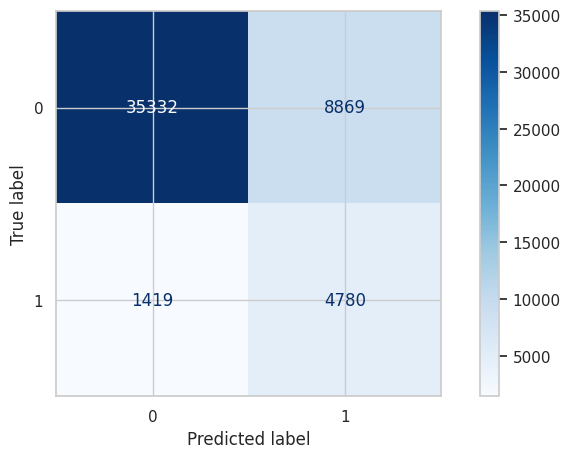

In [64]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Entraînement CatBoost avec class_weights pour gérer le déséquilibre des classes
params_init = {
    "iterations"   : 500,
    "learning_rate": 0.1,
    "depth"        : 6,
    "eval_metric"  : "AUC",
    "verbose"      : False,
    "class_weights": [1, 7.13],
    "random_seed"  : 42,
}

model = CatBoostClassifier(**params_init)
model.fit(Transformer.fit_transform(X_train), y_train)

y_pred = model.predict(Transformer.transform(X_val))

print("📄 Classification Report — CatBoost (initial) :")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(cmap='Blues')
plt.show()

---
## 11. 🎛️ Optimisation des Hyperparamètres <a id='11-optim'></a>

> Grid search avec cross-validation stratifiée pour trouver les meilleurs paramètres CatBoost.

In [65]:
# Paramètres fixes (non explorés par la grille)
base_params = {
    "iterations" : 500,
    "eval_metric": "AUC",
    "verbose"    : False,
    "random_seed": 42,
}

# Grille adaptée au déséquilibre des classes
grid = {
    "depth"        : [6, 7, 8],               # profondeur des arbres
    "learning_rate": [0.05, 0.1],             # taux d'apprentissage
    "l2_leaf_reg"  : [3, 5, 7],               # régularisation L2 contre l'overfitting
    "class_weights": [[1, 6], [1, 7], [1, 8]], # autour du ratio réel (~7)
    "border_count" : [32, 64, 128],            # nombre de bins pour les features numériques
}

# Création et grid search du modèle
model = CatBoostClassifier(**base_params)
model.grid_search(
    param_grid=grid,
    X=Transformer.fit_transform(X_train),
    y=y_train,
    cv=3,
    stratified=True,
    partition_random_seed=42,
    refit=True,
    verbose=False
)

print("\n✅ Meilleurs paramètres trouvés :")
print(model.get_params())


bestTest = 0.8066557539
bestIteration = 499

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8407792136
bestIteration = 499

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8065157973
bestIteration = 499

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8394355707
bestIteration = 498

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8074239417
bestIteration = 499

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8424250466
bestIteration = 499

Metric AUC is not calculated on train by default. To c

### 11.1 Entraînement du meilleur modèle

📄 Classification Report — Meilleur modèle CatBoost :
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     44201
           1       0.48      0.80      0.60      6199

    accuracy                           0.87     50400
   macro avg       0.73      0.84      0.76     50400
weighted avg       0.91      0.87      0.88     50400



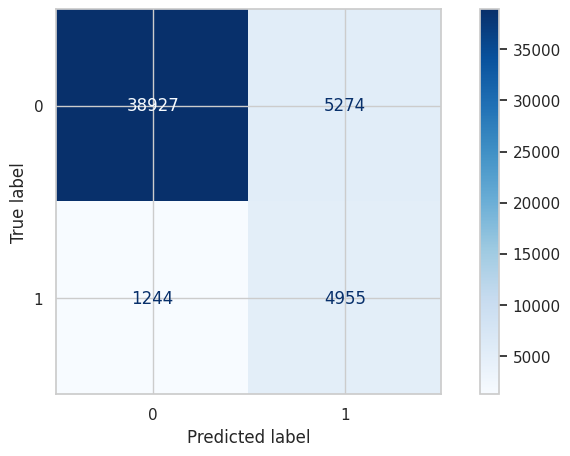

In [66]:
# Paramètres optimaux issus du grid search
best_params = {
    'iterations'   : 500,
    'random_seed'  : 42,
    'verbose'      : False,
    'eval_metric'  : 'AUC',
    'border_count' : 128,
    'depth'        : 8,
    'class_weights': [1, 6],
    'learning_rate': 0.1,
    'l2_leaf_reg'  : 3
}

# Entraînement du meilleur modèle sur tout le train set
best_model = CatBoostClassifier(**best_params)
best_model.fit(Transformer.fit_transform(X_train), y_train)

# Évaluation sur le jeu de validation
y_pred = best_model.predict(Transformer.transform(X_val))

print("📄 Classification Report — Meilleur modèle CatBoost :")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_).plot(cmap='Blues')
plt.show()

---
## 12. 📉 Analyse des Seuils de Décision <a id='12-threshold'></a>

> Recherche du seuil optimal de classification via la courbe ROC (critère de Youden).

### 12.1 Détermination du seuil optimal (Youden's J)

Seuil optimal (Youden's J) : 0.501

📄 Classification Report avec seuil optimal :
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     44201
           1       0.49      0.80      0.60      6199

    accuracy                           0.87     50400
   macro avg       0.73      0.84      0.76     50400
weighted avg       0.91      0.87      0.88     50400



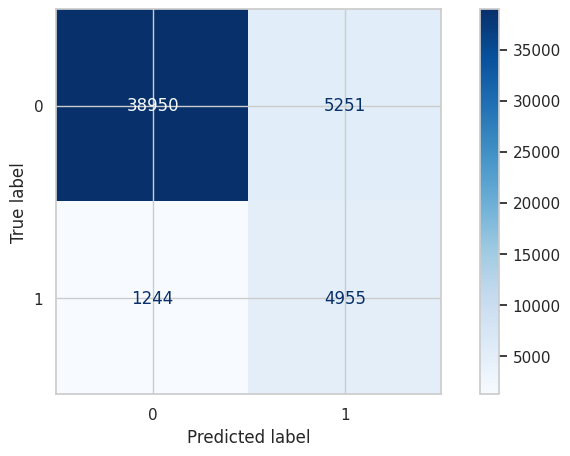

In [67]:
from sklearn.metrics import roc_curve

# Probabilités prédites pour la classe 1 (risqué)
y_proba = best_model.predict_proba(Transformer.transform(X_val))[:, 1]

# Calcul du seuil optimal via la statistique de Youden (max(TPR - FPR))
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Seuil optimal (Youden's J) : {best_threshold:.3f}")

# Application du seuil optimal
y_pred = (y_proba >= best_threshold).astype(int)

print("\n📄 Classification Report avec seuil optimal :")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_).plot(cmap='Blues')
plt.show()

### 12.2 Distribution des probabilités par classe

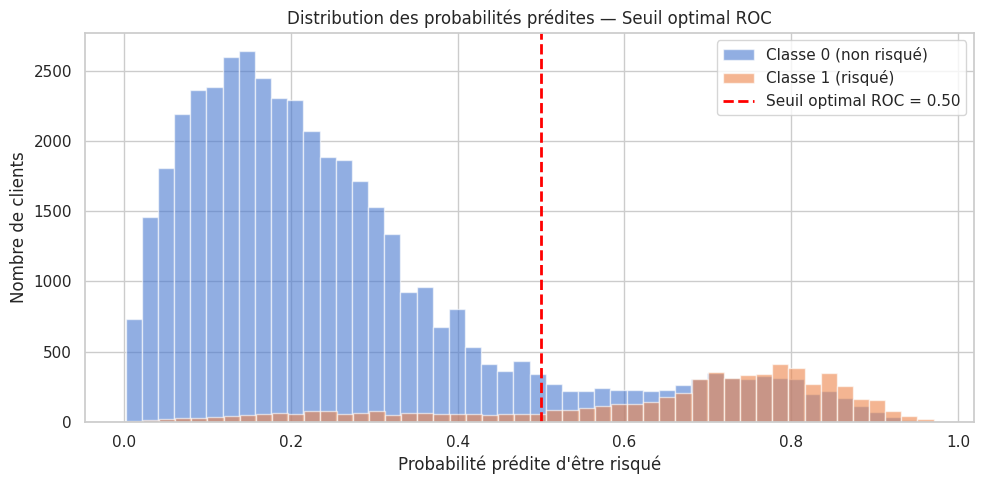

In [68]:
# Visualisation de la distribution des probabilités prédites selon la vraie classe
plt.figure(figsize=(10, 5))

plt.hist(y_proba[y_val == 0], bins=50, alpha=0.6, label='Classe 0 (non risqué)')
plt.hist(y_proba[y_val == 1], bins=50, alpha=0.6, label='Classe 1 (risqué)')

plt.axvline(
    best_threshold, color='red', linestyle='--', linewidth=2,
    label=f'Seuil optimal ROC = {best_threshold:.2f}'
)

plt.xlabel("Probabilité prédite d'être risqué")
plt.ylabel('Nombre de clients')
plt.title('Distribution des probabilités prédites — Seuil optimal ROC')
plt.legend()
plt.tight_layout()
plt.show()

# 📝 Interprétation proposée :
#   < 0.30 → profil sain (faible risque)
#   > 0.80 → profil risqué (forte confiance)
#   [0.30, 0.80] → zone grise (analyse manuelle recommandée)

---
## 13. 🔎 Interprétabilité — Valeurs SHAP <a id='13-shap'></a>

> Analyse de l'importance et de la direction d'effet de chaque feature via les valeurs SHAP.

In [69]:
# Préparation du Pool d'entraînement transformé pour le calcul SHAP
X_train_transformed = Transformer.transform(X_train)

train_pool = Pool(
    data=X_train_transformed,
    label=y_train
)

In [70]:
# Calcul des valeurs SHAP pour chaque observation du train
shap_values = best_model.get_feature_importance(
    data=train_pool,
    type="ShapValues"
)

# La dernière colonne est la valeur attendue (expected value) → on l'exclut
shap_contrib = shap_values[:, :-1]

# Récupération des noms de features après transformation
feature_names = Transformer.get_feature_names_out()

# Importance globale : moyenne des valeurs absolues SHAP (magnitude de l'effet)
shap_importance = np.abs(shap_contrib).mean(axis=0)

# Effet moyen signé (positif = augmente le risque prédit, négatif = le réduit)
shap_mean = shap_contrib.mean(axis=0)

# Tableau de synthèse trié par importance décroissante
shap_df = pd.DataFrame({
    'feature'        : feature_names,
    'importance_abs' : shap_importance,
    'shap_mean'      : shap_mean
}).sort_values('importance_abs', ascending=False)

print("🔝 Top 10 features les plus influentes (SHAP) :")
print(shap_df.head(10).to_string(index=False))

🔝 Top 10 features les plus influentes (SHAP) :
                                    feature  importance_abs  shap_mean
                 pipeline-1__income_per_age        0.358343  -0.280726
              pipeline-1__CURRENT_HOUSE_YRS        0.167485  -0.065754
                 pipeline-3__experience_bin        0.154859  -0.055315
                        pipeline-3__age_bin        0.144495  -0.046485
              pipeline-3__cur_job_years_bin        0.132690  -0.059474
                     pipeline-3__income_bin        0.132445   0.013927
             pipeline-2__Région_North India        0.109847  -0.020422
             pipeline-2__Région_South India        0.100356  -0.021639
pipeline-2__Catégorie de métier_Engineering        0.095921  -0.019442
              pipeline-2__Région_East India        0.093999  -0.018742


---
## 14. 💾 Sauvegarde du Modèle & du Transformer <a id='14-save'></a>

> Sérialisation du meilleur modèle CatBoost et du ColumnTransformer pour déploiement ou réutilisation future.

**Stratégie de sauvegarde :**
- `best_model` → format natif CatBoost (`.cbm`) : rapide, portable, supporte la reprise d'entraînement
- `Transformer` → sérialisation `joblib` (`.pkl`) : recommandé pour les objets scikit-learn
- `best_threshold` → inclus dans un fichier JSON de métadonnées : léger, lisible, versionnable
- Un fichier `metadata.json` compile toutes les informations utiles au déploiement


### 14.1 Création du répertoire de sauvegarde

In [8]:
import os
import joblib
import json
from datetime import datetime

# Répertoire de sauvegarde des artefacts
SAVE_DIR = '../Models'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Repertoire de sauvegarde : {os.path.abspath(SAVE_DIR)}')

Repertoire de sauvegarde : /home/franck/projects/Projet_Bachelor_Scoring/Models


### 14.2 Sauvegarde du modèle CatBoost (format natif `.cbm`)

In [72]:
# Sauvegarde au format natif CatBoost (.cbm)
# Avantages : compact, rapide a charger, compatible avec CatBoost en production
model_path = os.path.join(SAVE_DIR, 'best_model.cbm')
best_model.save_model(model_path)

print(f'Modele sauvegarde : {model_path}')
print(f'Taille : {os.path.getsize(model_path) / 1024:.1f} Ko')

Modele sauvegarde : ../Models/best_model.cbm
Taille : 2058.0 Ko


### 14.3 Sauvegarde du ColumnTransformer (format `joblib`)

In [73]:
# Sauvegarde du ColumnTransformer avec joblib
# joblib est prefere a pickle pour les objets scikit-learn
# (meilleure gestion des tableaux numpy et des pipelines complexes)
transformer_path = os.path.join(SAVE_DIR, 'column_transformer.pkl')
joblib.dump(Transformer, transformer_path)

print(f'Transformer sauvegarde : {transformer_path}')
print(f'Taille : {os.path.getsize(transformer_path) / 1024:.1f} Ko')

Transformer sauvegarde : ../Models/column_transformer.pkl
Taille : 7.1 Ko


### 14.4 Sauvegarde du seuil optimal et des métadonnées

In [74]:
# Compilation des metadonnees utiles au deploiement
metadata = {
    'date_entrainement'     : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'modele'                : 'CatBoostClassifier',
    'meilleurs_parametres'  : best_model.get_params(),
    'seuil_optimal_roc'     : float(best_threshold),
    'features_input'        : list(X_train.columns),
    'features_transformees' : list(Transformer.get_feature_names_out()),
    'variable_cible'        : 'Risk_Flag',
    'classes'               : [int(c) for c in best_model.classes_],
    'fichiers': {
        'modele'      : 'best_model.cbm',
        'transformer' : 'column_transformer.pkl',
        'metadata'    : 'metadata.json'
    }
}

# Sauvegarde du fichier de metadonnees
metadata_path = os.path.join(SAVE_DIR, 'metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f'Metadonnees sauvegardees : {metadata_path}')
print('\nContenu (extrait) :')
summary = {k: v for k, v in metadata.items() if k != 'meilleurs_parametres'}
print(json.dumps(summary, indent=4, ensure_ascii=False))

Metadonnees sauvegardees : ../Models/metadata.json

Contenu (extrait) :
{
    "date_entrainement": "2026-02-11 16:29",
    "modele": "CatBoostClassifier",
    "seuil_optimal_roc": 0.5005505684222314,
    "features_input": [
        "Married/Single",
        "House_Ownership",
        "Car_Ownership",
        "CURRENT_HOUSE_YRS",
        "Région",
        "Catégorie de métier",
        "income_per_age",
        "married_owns_house",
        "owns_car_high_income",
        "age_bin",
        "experience_bin",
        "income_bin",
        "cur_job_years_bin"
    ],
    "features_transformees": [
        "pipeline-1__CURRENT_HOUSE_YRS",
        "pipeline-1__income_per_age",
        "pipeline-2__Married/Single_single",
        "pipeline-2__House_Ownership_owned",
        "pipeline-2__House_Ownership_rented",
        "pipeline-2__Car_Ownership_yes",
        "pipeline-2__Région_East India",
        "pipeline-2__Région_North India",
        "pipeline-2__Région_North-East India",
        "pipe

### 14.5 Vérification — Rechargement et prédiction test

> On recharge les artefacts depuis le disque et on vérifie que les prédictions sont identiques à celles du modèle original.

In [9]:
from catboost import CatBoostClassifier
import joblib, json, numpy as np
import os

# --- Rechargement des artefacts depuis le disque ---
loaded_model = CatBoostClassifier()
loaded_model.load_model(os.path.join(SAVE_DIR, 'best_model.cbm'))

loaded_transformer = joblib.load(os.path.join(SAVE_DIR, 'column_transformer.pkl'))

with open(os.path.join(SAVE_DIR, 'metadata.json'), encoding='utf-8') as f:
    loaded_meta = json.load(f)

loaded_threshold = loaded_meta['seuil_optimal_roc']

# --- Prédiction sur un echantillon de validation ---
X_sample = X_val.head(5)
proba_reloaded  = loaded_model.predict_proba(loaded_transformer.transform(X_sample))[:, 1]
proba_original  = best_model.predict_proba(Transformer.transform(X_sample))[:, 1]

# --- Assertion : les probabilites doivent etre identiques ---
assert np.allclose(proba_reloaded, proba_original, atol=1e-6), 'Incoherence detectee !'

print('Rechargement valide - les probabilites sont identiques.')
print(f'\nSeuil recharge : {loaded_threshold:.3f}')
print('\nProbabilites predites (echantillon de 5 clients) :')
for i, p in enumerate(proba_reloaded):
    label = 'Risque' if p >= loaded_threshold else 'Sain'
    print(f'  Client {i+1} -> proba={p:.3f}  ({label})')

NameError: name 'X_val' is not defined

### 14.6 Récapitulatif des fichiers sauvegardés

| Fichier                  | Contenu                                     | Commande de rechargement         |
|--------------------------|---------------------------------------------|----------------------------------|
| `best_model.cbm`         | Modèle CatBoost entraîné                    | `model.load_model(path)`         |
| `column_transformer.pkl` | Pipeline de prétraitement scikit-learn      | `joblib.load(path)`              |
| `metadata.json`          | Paramètres, seuil, features, date           | `json.load(f)`                   |

```python
# Snippet prêt à l'emploi pour une prédiction en production
from catboost import CatBoostClassifier
import joblib, json

model       = CatBoostClassifier()
model.load_model('Models/best_model.cbm')
transformer = joblib.load('Models/column_transformer.pkl')

with open('Models/metadata.json') as f:
    meta = json.load(f)
threshold = meta['seuil_optimal_roc']

# Sur de nouvelles données brutes :
X_new_transformed = transformer.transform(X_new)
probas            = model.predict_proba(X_new_transformed)[:, 1]
labels            = (probas >= threshold).astype(int)  # 0 = sain, 1 = risqué
```


---

## ✅ Récapitulatif

| Étape | Résultat |
|-------|----------|
| Données | Aucun doublon, pas de valeurs manquantes |
| Déséquilibre | ~87% sain / ~13% risqué → géré via `class_weights` |
| Feature Engineering | 7 nouvelles features créées (bins, combinaisons, région, catégorie métier) |
| Modèle retenu | **CatBoostClassifier** (supérieur à la Régression Logistique) |
| Seuil optimal | Déterminé via la courbe ROC (critère de Youden's J) |
| Interprétabilité | Analyse SHAP pour identifier les features les plus impactantes |

In [35]:
import numpy as np
import pandas as pd

def preprocess_dataframe(df):
    df = df.copy()

    # =========================
    # 1️⃣ Mapping des professions
    # =========================
    def map_profession(profession):
    # Normaliser — remplace les espaces par underscores pour matcher les deux formats
        p = profession.replace(' ', '_')

        if p in [
            'Mechanical_engineer', 'Civil_engineer', 'Design_Engineer',
            'Chemical_engineer', 'Biomedical_Engineer', 'Petroleum_Engineer',
            'Industrial_Engineer', 'Engineer', 'Architect',
            'Surveyor', 'Geologist', 'Drafter']:
            return 'Engineering'

        elif p in [
            'Software_Developer', 'Web_designer', 'Computer_hardware_engineer',
            'Computer_operator', 'Technology_specialist', 'Technician']:
            return 'Technology & IT'

        elif p in [
            'Analyst', 'Financial_Analyst', 'Statistician',
            'Economist', 'Consultant']:
            return 'IT, Data & Analytics'

        elif p in [
            'Physician', 'Dentist', 'Surgeon',
            'Psychologist', 'Microbiologist', 'Scientist']:
            return 'Healthcare & Medical'

        elif p in [
            'Designer', 'Graphic_Designer', 'Fashion_Designer',
            'Artist', 'Comedian']:
            return 'Creative, Design & Media'

        elif p in [
            'Civil_servant', 'Politician', 'Police_officer',
            'Magistrate', 'Lawyer', 'Official', 'Firefighter']:
            return 'Law, Government & Public Service'

        elif p in [
            'Chartered_Accountant', 'Secretary', 'Hotel_Manager',
            'Administrative_Officer', 'Manager']:
            return 'Business, Finance & Administration'

        elif p in [
            'Aviator', 'Flight_attendant',
            'Air_traffic_controller', 'Army_officer']:
            return 'Aviation, Defense & Security'

        elif p in [
            'Librarian', 'Technical_writer', 'Teacher',
            'Professor', 'Researcher']:
            return 'Education, Research & Documentation'

        elif p in [
            'Chef', 'Waiter', 'Steward',
            'Housekeeper', 'Receptionist']:
            return 'Hospitality & Services'

        else:
            return profession  # retourne tel quel si non mappé




    df['Catégorie de métier'] = df['Profession'].apply(map_profession)

    # =========================
    # 2️⃣ Mapping des régions
    # =========================
    def map_state_to_region(state):
        north_india = ['Delhi', 'Haryana', 'Punjab', 'Rajasthan', 'Uttar_Pradesh',
                       'Uttar_Pradesh[5]', 'Uttarakhand', 'Himachal_Pradesh',
                       'Jammu_and_Kashmir', 'Chandigarh']
        south_india = ['Tamil_Nadu', 'Kerala', 'Karnataka', 'Telangana',
                       'Andhra_Pradesh', 'Puducherry']
        west_india = ['Maharashtra', 'Gujarat']
        east_india = ['West_Bengal', 'Odisha', 'Bihar', 'Jharkhand']
        central_india = ['Madhya_Pradesh', 'Chhattisgarh']

        if state in north_india:
            return 'North India'
        elif state in south_india:
            return 'South India'
        elif state in west_india:
            return 'West India'
        elif state in east_india:
            return 'East India'
        elif state in central_india:
            return 'Central India'
        else:
            return 'North-East India'

    df['Région'] = df['STATE'].apply(map_state_to_region)

    # =========================
    # 3️⃣ Feature engineering
    # =========================
    df['income_per_age'] = df['Income'] / df['Age']

    df['married_owns_house'] = np.where(
        (df['Married/Single'] == 'married') &
        (df['House_Ownership'] == 'owned'),
        'yes', 'no'
    )

    df['owns_car_high_income'] = np.where(
        (df['Car_Ownership'] == 'yes') &
        (df['Income'] > df['Income'].median()),
        'yes', 'no'
    )

    # =========================
    # 4️⃣ Binning
    # =========================
    df['age_bin'] = pd.cut(
        df['Age'],
        bins=[20, 30, 40, 50, 60, 80],
        labels=['21-30', '31-40', '41-50', '51-60', '61-80']
    )

    df['experience_bin'] = pd.cut(
        df['Experience'],
        bins=[-1, 2, 5, 10, 15, 20],
        labels=['0-2', '3-5', '6-10', '11-15', '16-20']
    )

    df['income_bin'] = pd.cut(
        df['Income'],
        bins=[0, 2_000_000, 4_000_000, 6_000_000, 8_000_000, 10_000_000],
        labels=['0-2M', '2-4M', '4-6M', '6-8M', '8-10M'],
        include_lowest=True
    )

    df['cur_job_years_bin'] = pd.cut(
        df['CURRENT_JOB_YRS'],
        bins=[-1, 2, 5, 9, 14],
        labels=['0-2', '3-5', '6-9', '10-14']
    )

    # =========================
    # 5️⃣ Suppression colonnes brutes
    # =========================
    df = df.drop(
        ['Profession', 'CITY', 'STATE',
         'Income', 'Age', 'Experience', 'CURRENT_JOB_YRS','ID'],
        axis=1,
        errors='ignore'
    )

    return df